In [13]:
import pandas as pd
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

In [14]:
'''************************************* DB CONNECTION *********************************'''

# 1) Connect to DB  (edit credentials as needed)

#### Database Connection Setup

# Load credentials (like DB_USER, DB_PASS, etc.) from the .env file
load_dotenv()

# Retrieve database credentials from environment variables
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# Build the PostgreSQL connection string dynamically using credentials
DB_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Initialize the SQLAlchemy engine to manage the connection to the database
# 'pool_pre_ping=True' ensures stale connections are checked before use
engine = create_engine(DB_URL, pool_pre_ping=True)

# Confirm successful connection
print("The connection to the DB has been successfully established ✅")

The connection to the DB has been successfully established ✅


In [15]:
# Load your zip/county file
zips = pd.read_csv("../dimensions/fl_selected_counties_zipcodes.csv")[["zip_code", "county"]]


# Create a temporary table and load the zip/county data into it
with engine.begin() as conn:
    conn.execute(text("""
        CREATE TEMP TABLE zips (
            zip_code text,
            county   text
        );
    """))
    zips.to_sql("zips", conn, if_exists="append", index=False)



In [16]:
query =f"""SELECT
            s.*,
            z.county
        FROM standardized_cpt_columns s
        JOIN zips z
            ON LEFT(s."ZIP4"::text, 5) = LEFT(z.zip_code::text, 5)
        WHERE
            (s."standard_charge_negotiated_dollar" IS NOT NULL
             OR s."standard_charge_negotiated_percentage" IS NOT NULL)
            AND s."specification" IN (
                'United Health Care',
                'Cigna',
                'Aetna',
                'Blue Cross Blue Shield',
                'Medicare',
                'Medicaid'
            )
            AND s."bucket" in ('Government', 'Commercial')
"""

In [17]:

with engine.connect() as conn:
    result = conn.execute(text(query))   # the big query
    rows = result.fetchall()             # get all rows
    cols = result.keys()                 # column names

working_df = pd.DataFrame(rows, columns=cols)
working_df["ZIP4"] = working_df["ZIP4"].astype(str).str[:5]
# normalize column names to lowercase
working_df.columns = working_df.columns.str.lower()


print("Rows loaded:", len(working_df))
print("Columns:", working_df.columns.tolist())
working_df.head()



Rows loaded: 1242695
Columns: ['index', 'hospital_name', 'hospital_address_single', 'zip4', 'setting', 'modifiers', 'standard_charge_gross', 'standard_charge_discounted_cash', 'payer_name', 'plan_name', 'standard_charge_negotiated_dollar', 'standard_charge_negotiated_percentage', 'standard_charge_min', 'standard_charge_max', 'bucket', 'specification', 'specification_plan', 'cpt_code', 'description', 'simple description', 'specialty', 'category', 'rate_using_min', 'rate_using_max', 'county']


,index,hospital_name,hospital_address_single,zip4,setting,modifiers,standard_charge_gross,standard_charge_discounted_cash,payer_name,plan_name,...,specification,specification_plan,cpt_code,description,simple description,specialty,category,rate_using_min,rate_using_max,county
0,0,Good Samaritan Medical Center,"1309 N Flagler Dr, West Palm Beach, FL 33401",33401,outpatient,None,NaN,NaN,molina healthcare,of texas (claims only) molinacompletecaremgdmcaid,...,Medicaid,Medicaid,90836,"Individual Psychotherapy, 45 min, performed wi...","Individual Psychotherapy, 45 min., with medica...",Psychiatry/Psychology,Psychotherapy w/ E/M,0.9500,0.95,Palm Beach
1,1,Good Samaritan Medical Center,"1309 N Flagler Dr, West Palm Beach, FL 33401",33401,outpatient,GO,313.0,234.75,molina healthcare,of texas (claims only) molinacompletecaremgdmcaid,...,Medicaid,Medicaid,97140,"Manual therapy techniques (e.g., mobilization,...","Manual physical therapy, 15 min.",Physical Medicine & Rehabilitation,Therapeutic Procedure,297.3500,297.35,Palm Beach
2,2,Good Samaritan Medical Center,"1309 N Flagler Dr, West Palm Beach, FL 33401",33401,outpatient,None,NaN,NaN,molina healthcare,of texas (claims only) molinacompletecaremgdmcaid,...,Medicaid,Medicaid,93296,Interrogation device evaluation (in person or ...,Evaluation of an implanted pacemaker or defibr...,Cardiology,Cardiovascular Monitoring,0.9500,0.95,Palm Beach
3,22,Good Samaritan Medical Center,"1309 N Flagler Dr, West Palm Beach, FL 33401",33401,outpatient,None,NaN,NaN,wellcare,centenehnwellcaremgdmcare,...,Medicare,Medicare,46742,Repair of high imperforate anus with rectovagi...,"Surgical repair of imperforate anus, severe bi...",Pediatric Surgery,Surgery (Anus/Rectum),0.2375,9009.50,Palm Beach
4,82,Good Samaritan Medical Center,"1309 N Flagler Dr, West Palm Beach, FL 33401",33401,outpatient,None,NaN,NaN,wellcare,centenehnwellcaremgdmcare,...,Medicare,Medicare,50548,"Laparoscopy, surgical, nephrectomy, complete.","Kidney removal, minimally invasive",Urology,Surgery (Urinary System),0.2375,9009.50,Palm Beach


In [18]:
import sys
import os

# add parent directory to the Python path
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from working_df import  filtered_df 

working_df = filtered_df()

The connection to the DB has been successfully established ✅
Rows loaded: 1242695
Columns: ['index', 'hospital_name', 'hospital_address_single', 'zip4', 'setting', 'modifiers', 'standard_charge_gross', 'standard_charge_discounted_cash', 'payer_name', 'plan_name', 'standard_charge_negotiated_dollar', 'standard_charge_negotiated_percentage', 'standard_charge_min', 'standard_charge_max', 'bucket', 'specification', 'specification_plan', 'cpt_code', 'description', 'simple description', 'specialty', 'category', 'rate_using_min', 'rate_using_max', 'county']


In [19]:
# ============================================================
#  🔍 SANITY CHECK: Compare Raw Table Size vs Filtered Dataset
# ============================================================

# 1) Get total number of rows in the raw standardized_cpt_columns table
raw_rows_query = "SELECT COUNT(*) AS n FROM standardized_cpt_columns;"
raw_rows = pd.read_sql(raw_rows_query, engine)["n"][0]

# 2) Get number of rows in the filtered dataset (working_df)
filtered_rows = len(working_df)
distinct_zip4 = working_df["zip4"].nunique()
distinct_hospital_address = working_df["hospital_address_single"].nunique()
distinct_cpt_code = working_df["cpt_code"].nunique()

# 3) Print comparison results
print("===============================================")
print("📊 ROW COUNT COMPARISON")
print("===============================================")
print(f"Total rows in standardized_cpt_columns (raw):   {raw_rows:,}")
print(f"Rows after applying all filters (working_df):   {filtered_rows:,}")
print(f"Rows removed by filtering:                      {raw_rows - filtered_rows:,}")
print(f"Distinct ZIP4 values in working_df: {distinct_zip4:,}")
print(f"Distinct hospital addresses in working_df: {distinct_hospital_address:,}")
print(f"Distinct CPT codes in working_df: {distinct_cpt_code:,}")
print("===============================================")

📊 ROW COUNT COMPARISON
Total rows in standardized_cpt_columns (raw):   10,799,715
Rows after applying all filters (working_df):   1,242,695
Rows removed by filtering:                      9,557,020
Distinct ZIP4 values in working_df: 99
Distinct hospital addresses in working_df: 143
Distinct CPT codes in working_df: 122


In [20]:
# ============================================================
#  🔍 SANITY CHECK: Full Descriptive Stats for Each CPT Code
#  Purpose:
#     · Validate our filtered dataset vs Power BI outputs
#     · Understand the distribution shape for each CPT
#     · Justify the use of MEDIAN over MEAN under high skew
# ============================================================

import pandas as pd

# 1) Compute descriptive statistics: mean, median, min, max
cpt_basic_stats = (
    working_df
        .groupby("cpt_code")["rate_using_max"]
        .agg(
            mean_rate="mean",
            median_rate="median",
            min_rate="min",
            max_rate="max"
        )
)

# 2) Compute skewness separately
cpt_skew = (
    working_df
        .groupby("cpt_code")["rate_using_max"]
        .skew()
        .rename("skewness")
)

# 3) Combine everything into a single table
cpt_sanity_check = (
    pd.concat([cpt_basic_stats, cpt_skew], axis=1)
      .reset_index()
      .sort_values("skewness", ascending=False)   # show most skewed first
      .round(2)
)

# 4) Display most skewed CPT codes (top 15)
print("====================================================")
print("📊 SANITY CHECK — MEAN / MEDIAN / MIN / MAX / SKEWNESS BY CPT")
print("====================================================")
print(cpt_sanity_check.head(15))

# Optional: display least skewed CPT codes (bottom 10)
print("\n====================================================")
print("🧊 LEAST SKEWED CPT CODES")
print("====================================================")
print(cpt_sanity_check.tail(10))


📊 SANITY CHECK — MEAN / MEDIAN / MIN / MAX / SKEWNESS BY CPT
    cpt_code  mean_rate  median_rate  min_rate  max_rate  skewness
69     90471      82.39        76.44      0.51   17911.0     77.87
101    97110     105.71        52.70      4.53   17911.0     38.31
100    97035     105.32        43.50      0.95   17911.0     36.92
108    97530     107.52        48.48      4.43   17911.0     35.33
103    97116     113.08        48.58      4.53   17911.0     32.77
104    97140     123.70        76.25      4.07   17911.0     32.44
105    97161     201.43       157.05      9.60   17911.0     31.69
102    97112     127.78        51.68      4.28   17911.0     29.45
107    97164     189.37       125.71      5.28   17911.0     27.67
106    97162     242.44       161.53     13.06   17911.0     27.51
109    97535     127.82        48.00      4.42   17911.0     26.63
74     90834     295.35       225.88      0.95   13395.0     21.35
72     90832     262.10       181.53      0.95   13395.0     21.01
7

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


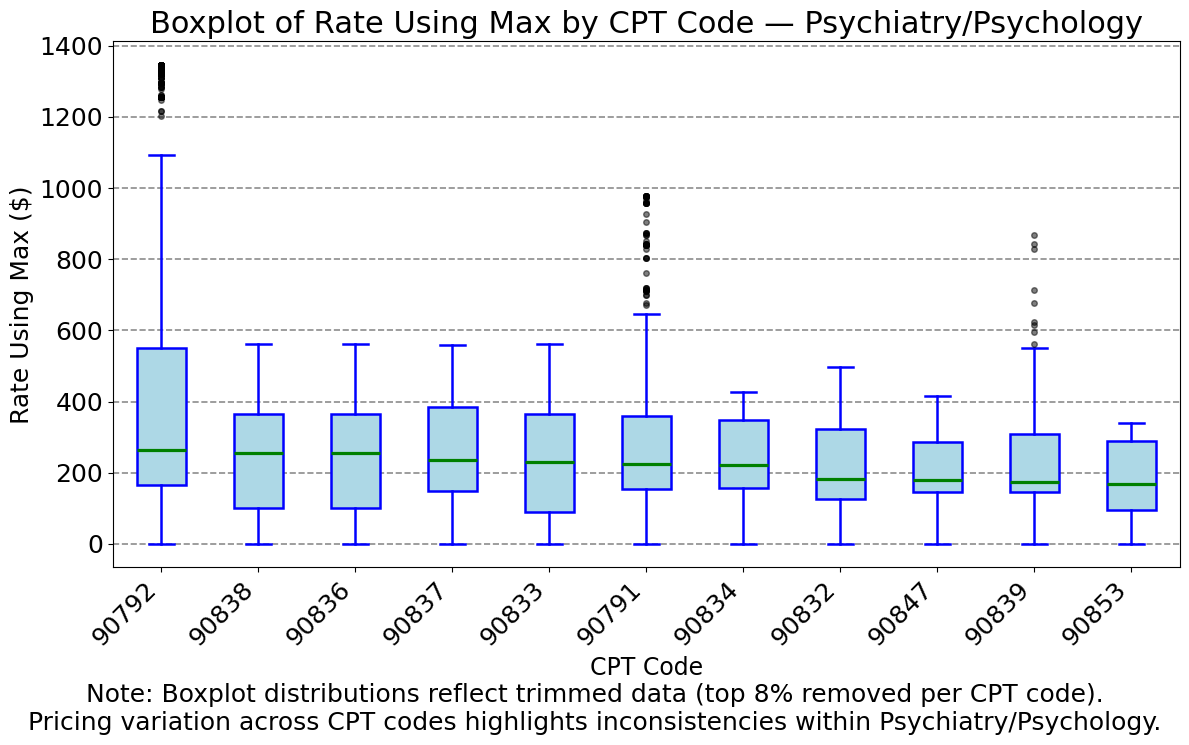

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


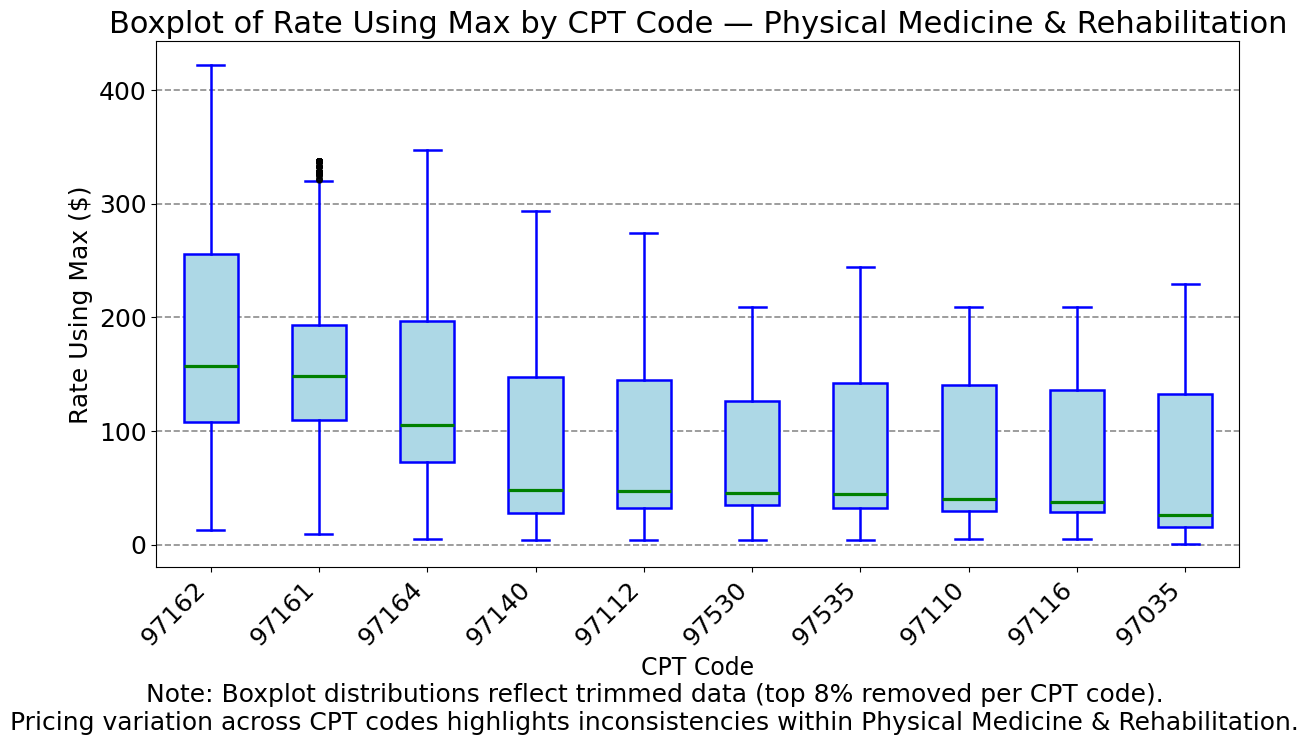

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


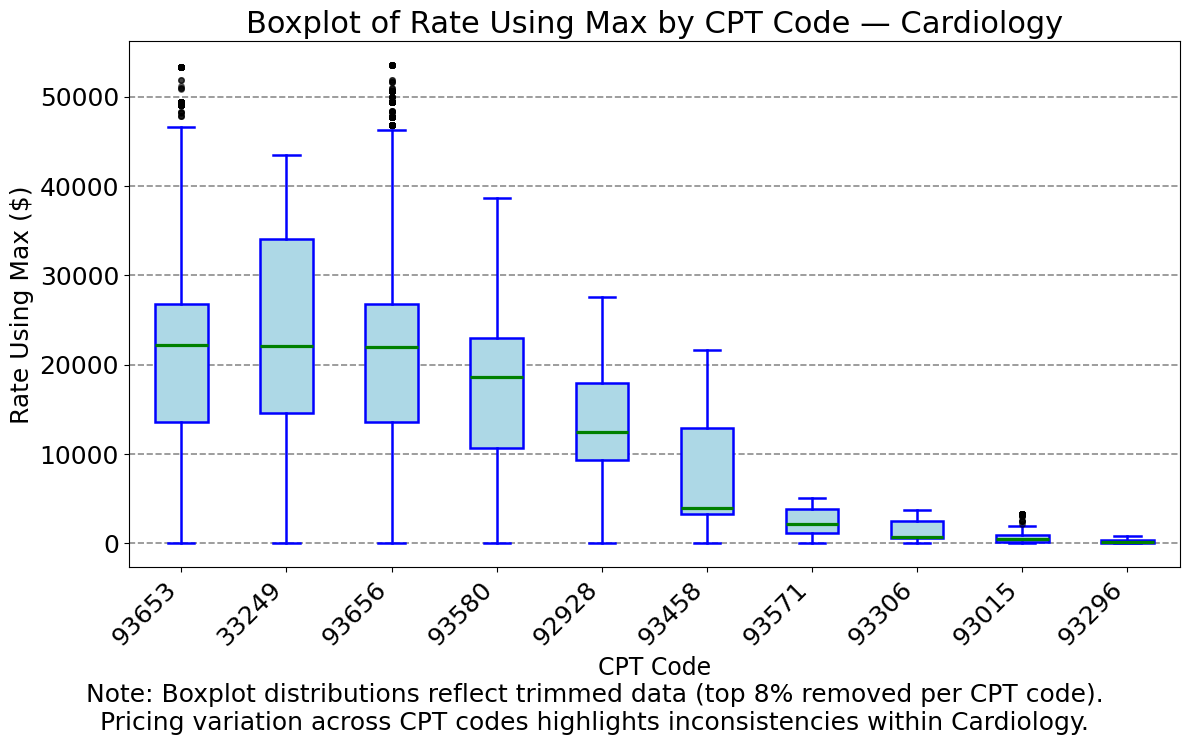

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


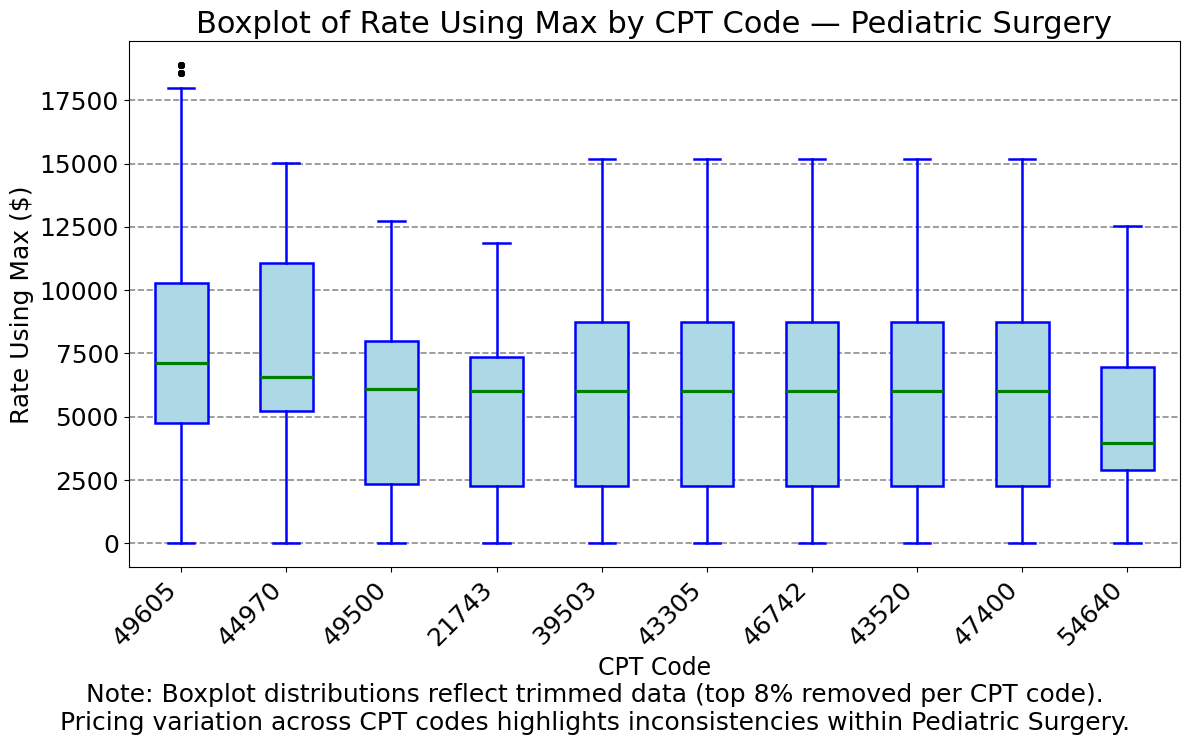

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


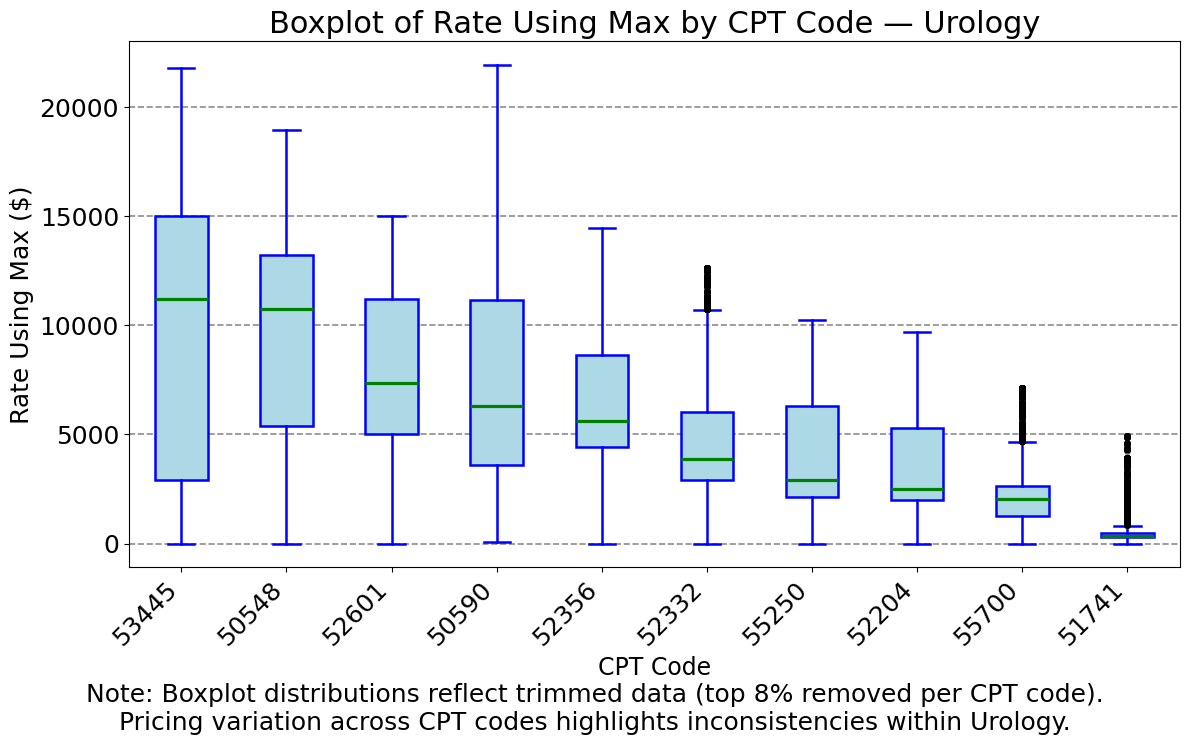

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


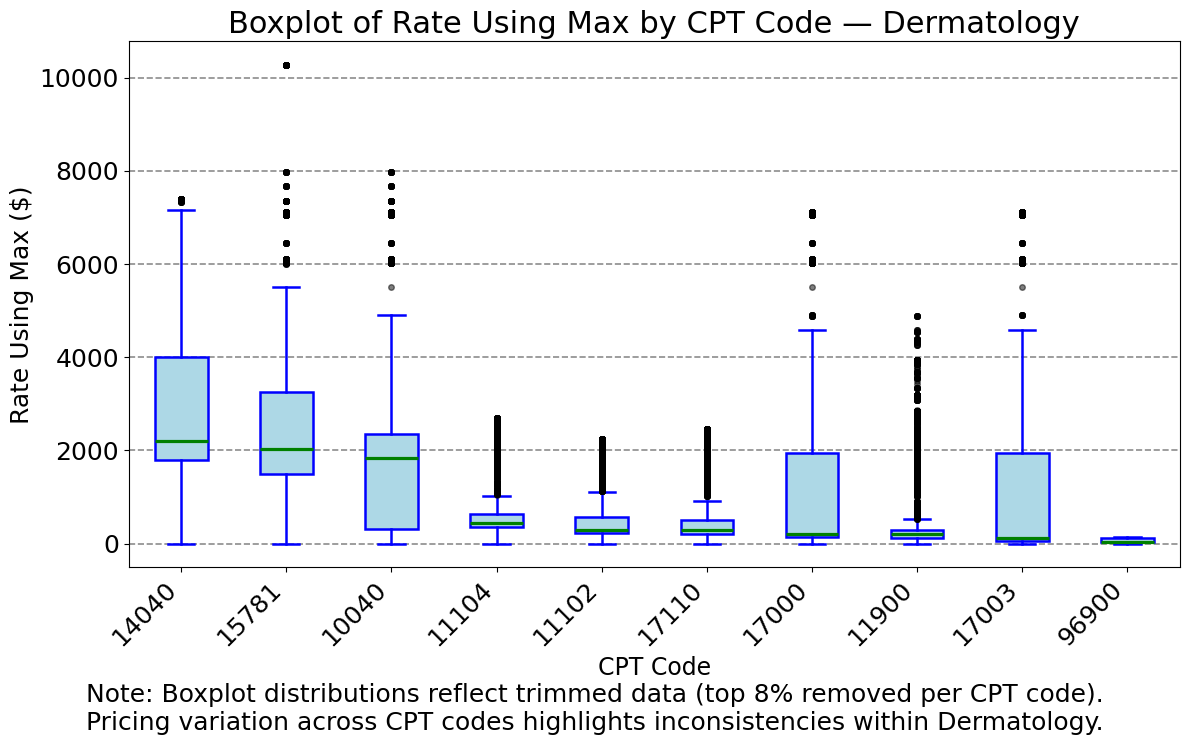

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


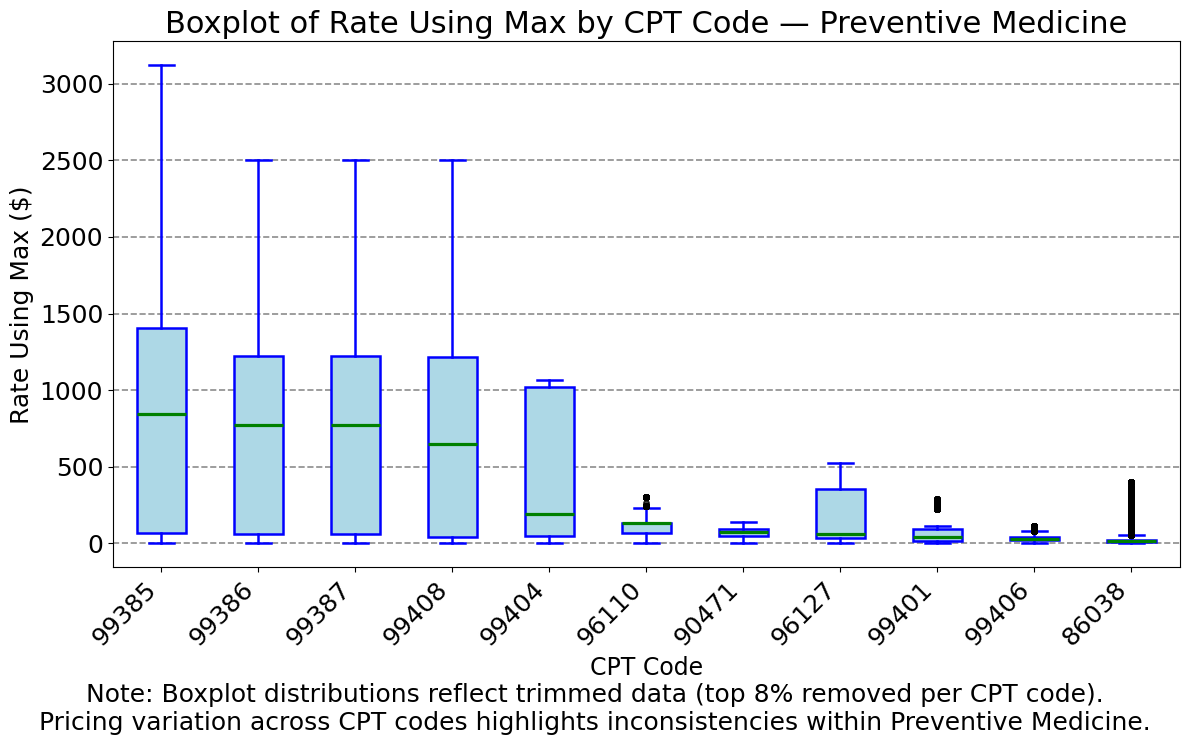

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


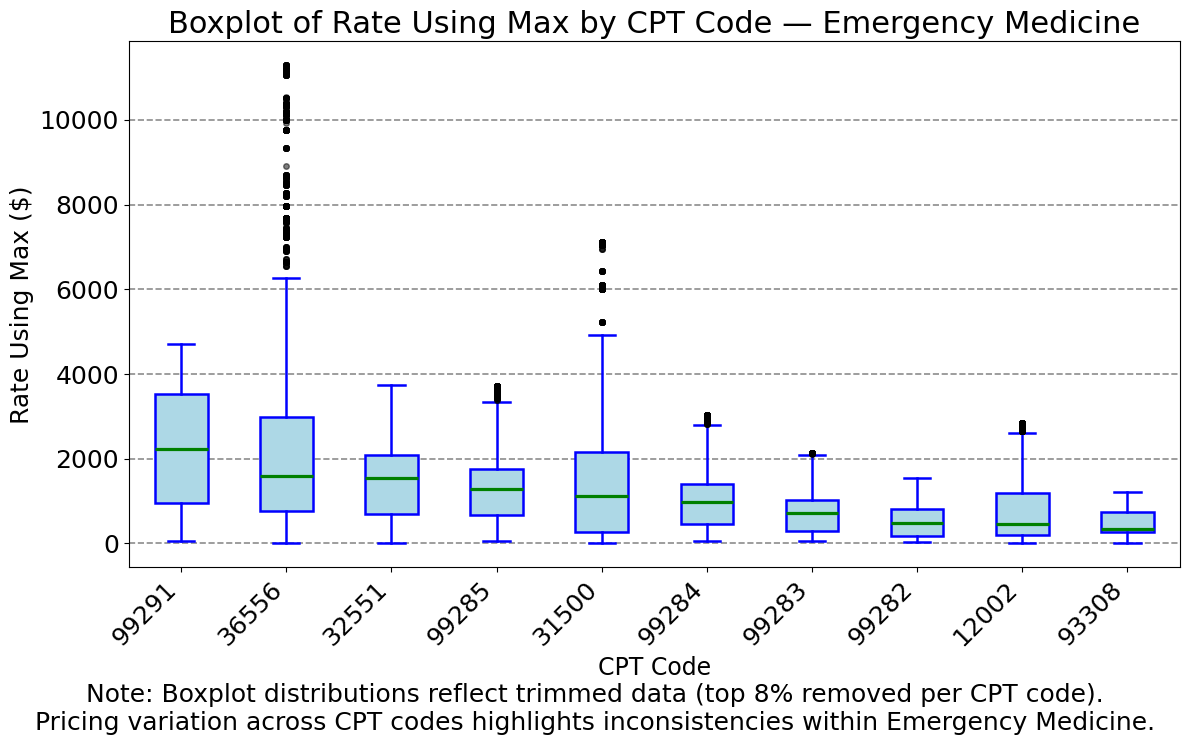

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


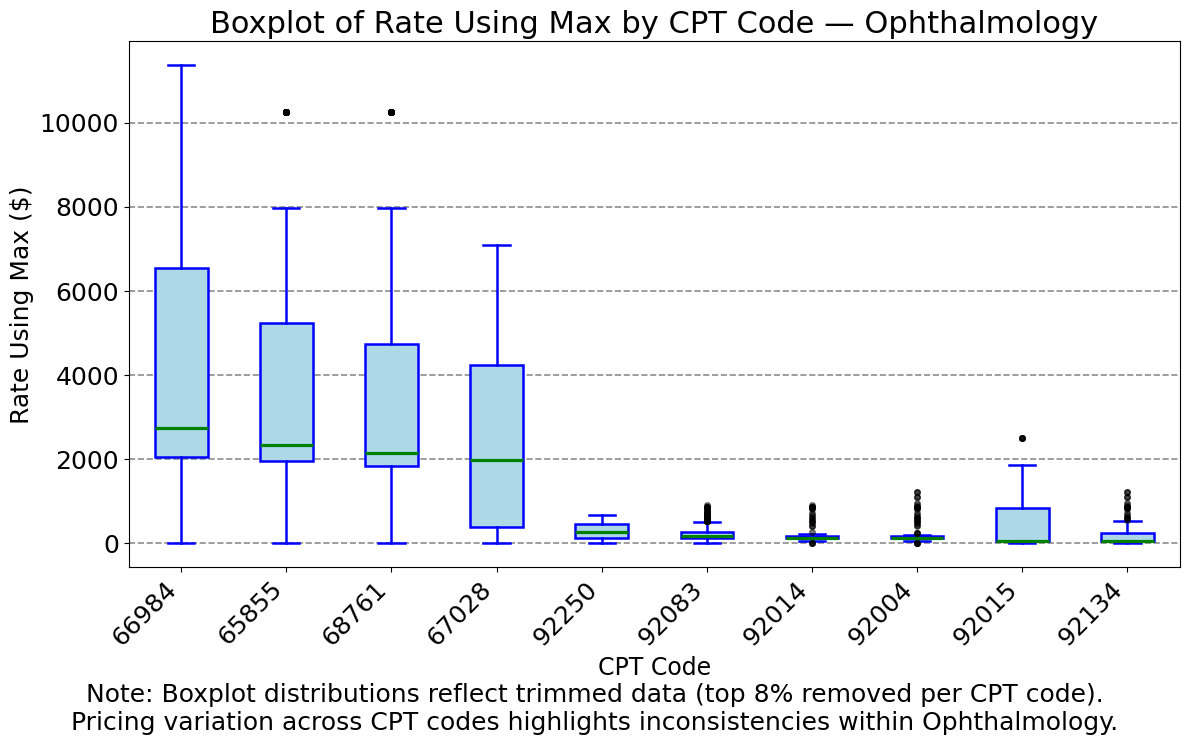

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


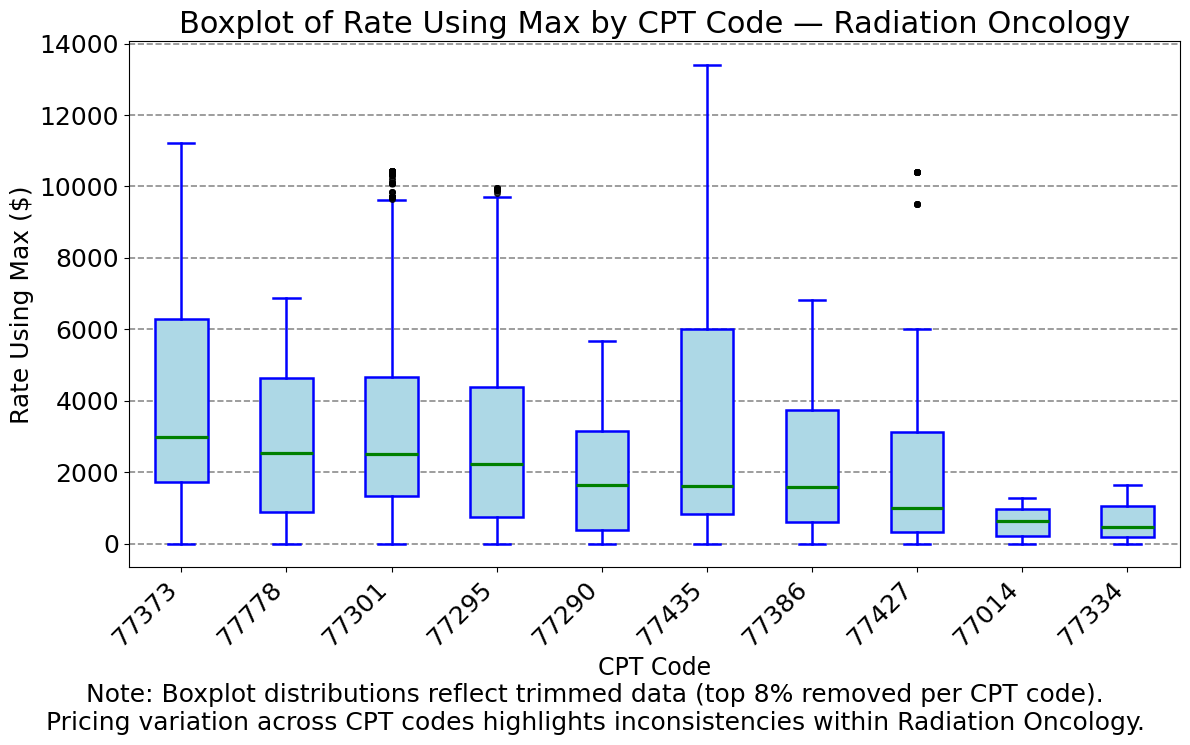

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


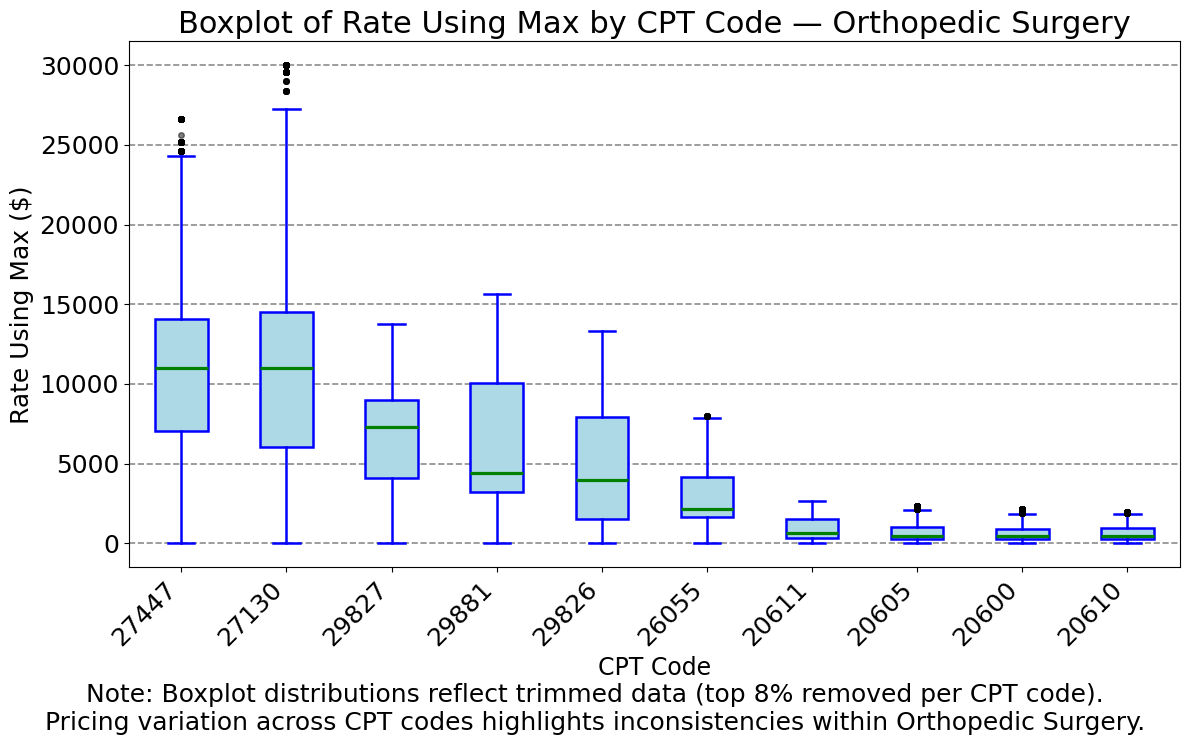

C:\Users\ss318889\AppData\Local\Temp\ipykernel_8952\3675386823.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


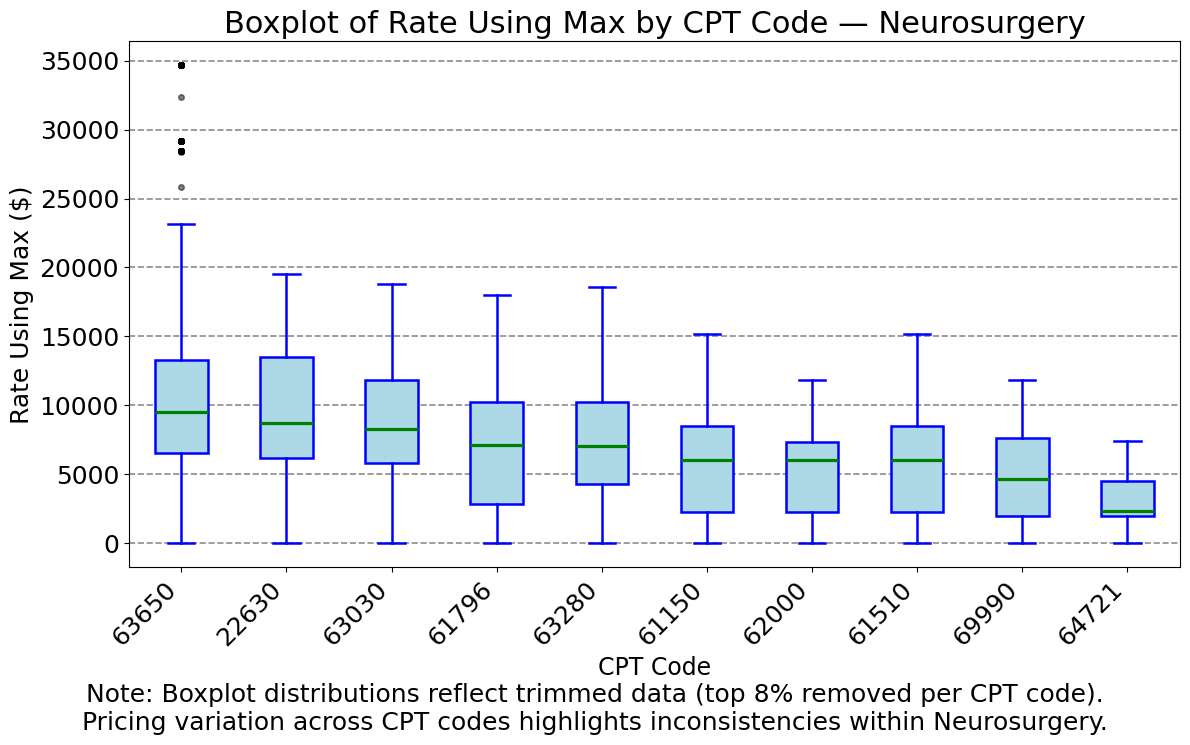

In [25]:
# import matplotlib.pyplot as plt
# import numpy as np

# specialties = working_df["specialty"].dropna().unique()

# for spec in specialties:
#     subset = working_df.loc[working_df["specialty"] == spec].copy()

#     # Trim top 8% per CPT
#     cutoff = subset.groupby("cpt_code")["rate_using_max"].transform(lambda s: s.quantile(0.92))
#     subset_plot = subset[subset["rate_using_max"] <= cutoff]

#     # Sort CPT codes
#     cpts = sorted(subset_plot["cpt_code"].unique())
#     cpt_labels = [str(c) for c in cpts]

#     # Spacing
#     positions = np.arange(len(cpts)) * 0.4
#     box_width = 0.20

#     # Data
#     data = [
#         subset_plot.loc[subset_plot["cpt_code"] == c, "rate_using_max"].values
#         for c in cpts
#     ]

#     plt.figure(figsize=(12, 7))

#     # Horizontal grid only
#     plt.grid(axis='y', linestyle='--', linewidth=1.2, color='gray', alpha=0.9)

#     bp = plt.boxplot(
#         data,
#         positions=positions,
#         widths=box_width,
#         patch_artist=True,
#         labels=None,
#         boxprops=dict(color="blue", linewidth=1.8),
#         medianprops=dict(color="green", linewidth=2.3),
#         whiskerprops=dict(color="blue", linewidth=1.8),
#         capprops=dict(color="blue", linewidth=1.8),
#         flierprops=dict(marker="o", markersize=4, markerfacecolor="black", alpha=0.5)
#     )

#     # Fill boxes light blue
#     for box in bp["boxes"]:
#         box.set(facecolor="#add8e6")

#     # Reduce left/right empty space
#     plt.xlim(positions[0] - 0.2, positions[-1] + 0.2)

#     # Diagonal X labels
#     plt.xticks(positions, cpt_labels, rotation=45, ha='right', fontsize=18)
#     plt.yticks(fontsize=18)

#     plt.xlabel("CPT Code", fontsize=17)
#     plt.ylabel("Rate Using Max ($)", fontsize=18)

#     plt.title(f"Boxplot of Rate Using Max by CPT Code — {spec}", fontsize=22)

#     # Two-line footnote (clean, clear, professional)
#     plt.figtext(
#         0.5, -0.05,
#         "Note: Boxplot distributions reflect trimmed data (top 8% removed per CPT code).\n"
#         f"Pricing variation across CPT codes highlights inconsistencies within {spec}.",
#         ha='center', fontsize=18
#     )

#     plt.tight_layout()
#     plt.show()


import matplotlib.pyplot as plt
import numpy as np

specialties = working_df["specialty"].dropna().unique()

for spec in specialties:
    subset = working_df.loc[working_df["specialty"] == spec].copy()

    # --- Trim top 8% per CPT (same as you had) ---
    cutoff = subset.groupby("cpt_code")["rate_using_max"].transform(lambda s: s.quantile(0.92))
    subset_plot = subset[subset["rate_using_max"] <= cutoff]

    # --- NEW: compute median per CPT (on trimmed data) and sort descending ---
    medians = subset_plot.groupby("cpt_code")["rate_using_max"].median()
    cpts = medians.sort_values(ascending=False).index.tolist()   # <-- DESC by median
    cpt_labels = [str(c) for c in cpts]

    # Spacing (same idea as you had, just based on the NEW cpts order)
    positions = np.arange(len(cpts)) * 0.4
    box_width = 0.20

    # Data (same, but now follows the NEW sorted CPT order)
    data = [
        subset_plot.loc[subset_plot["cpt_code"] == c, "rate_using_max"].values
        for c in cpts
    ]

    plt.figure(figsize=(12, 7))

    # Horizontal grid only
    plt.grid(axis='y', linestyle='--', linewidth=1.2, color='gray', alpha=0.9)

    bp = plt.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        labels=None,
        boxprops=dict(color="blue", linewidth=1.8),
        medianprops=dict(color="green", linewidth=2.3),
        whiskerprops=dict(color="blue", linewidth=1.8),
        capprops=dict(color="blue", linewidth=1.8),
        flierprops=dict(marker="o", markersize=4, markerfacecolor="black", alpha=0.5)
    )

    # Fill boxes light blue
    for box in bp["boxes"]:
        box.set(facecolor="#add8e6")

    # Reduce left/right empty space
    plt.xlim(positions[0] - 0.2, positions[-1] + 0.2)

    # Diagonal X labels
    plt.xticks(positions, cpt_labels, rotation=45, ha='right', fontsize=18)
    plt.yticks(fontsize=18)

    plt.xlabel("CPT Code", fontsize=17)
    plt.ylabel("Rate Using Max ($)", fontsize=18)

    plt.title(f"Boxplot of Rate Using Max by CPT Code — {spec}", fontsize=22)

    plt.figtext(
        0.5, -0.05,
        "Note: Boxplot distributions reflect trimmed data (top 8% removed per CPT code).\n"
        f"Pricing variation across CPT codes highlights inconsistencies within {spec}.",
        ha='center', fontsize=18
    )

    plt.tight_layout()
    plt.show()


In [26]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

COUNTY_COL = "county"
CPT_COL    = "cpt_code"
HOSP_COL   = "hospital_name"
PAYER_COL  = "bucket"
PRICE_COL  = "rate_using_max"

COMM_VALUE = "Commercial"
GOV_VALUE  = "Government"

MIN_HOSPS_PER_GROUP = 5
EPS = 1e-9

def _iqr(x: pd.Series) -> float:
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    return float(q3 - q1)

def hospital_level_median(df: pd.DataFrame) -> pd.DataFrame:
    d = df[[COUNTY_COL, CPT_COL, HOSP_COL, PAYER_COL, PRICE_COL]].copy()
    d = d.dropna(subset=[COUNTY_COL, CPT_COL, HOSP_COL, PAYER_COL, PRICE_COL])
    return (
        d.groupby([COUNTY_COL, CPT_COL, HOSP_COL, PAYER_COL], dropna=False)[PRICE_COL]
         .median()
         .reset_index(name="hosp_price")
    )

def build_county_cpt_dispersion(df: pd.DataFrame) -> pd.DataFrame:
    h = hospital_level_median(df)
    summ = (
        h.groupby([COUNTY_COL, CPT_COL, PAYER_COL])["hosp_price"]
         .agg(n_hosp="count", iqr=_iqr)
         .reset_index()
    )
    summ = summ[summ["n_hosp"] >= MIN_HOSPS_PER_GROUP].copy()

    wide = summ.pivot_table(
        index=[COUNTY_COL, CPT_COL],
        columns=PAYER_COL,
        values=["iqr", "n_hosp"],
        aggfunc="first"
    )
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    need = [f"iqr_{COMM_VALUE}", f"iqr_{GOV_VALUE}", f"n_hosp_{COMM_VALUE}", f"n_hosp_{GOV_VALUE}"]
    wide = wide.dropna(subset=need).copy()

    return wide.rename(columns={
        f"iqr_{COMM_VALUE}": "iqr_Commercial",
        f"iqr_{GOV_VALUE}":  "iqr_Government",
        f"n_hosp_{COMM_VALUE}": "n_hosp_Commercial",
        f"n_hosp_{GOV_VALUE}":  "n_hosp_Government",
    })

def run_test_D(df: pd.DataFrame, alternative: str = "two-sided") -> dict:
    m = build_county_cpt_dispersion(df).copy()
    m = m[(m["iqr_Commercial"] > 0) & (m["iqr_Government"] > 0)].copy()

    m["disp_diff"] = m["iqr_Commercial"] - m["iqr_Government"]
    median_disp_diff = float(m["disp_diff"].median())
    share_disp_diff_pos = float((m["disp_diff"] > 0).mean())

    m["disp_ratio"] = (m["iqr_Commercial"] + EPS) / (m["iqr_Government"] + EPS)
    m["log_disp_ratio"] = np.log(m["disp_ratio"])
    median_ratio = float(m["disp_ratio"].median())
    median_pct_wider = float((median_ratio - 1) * 100)
    share_ratio_gt1 = float((m["disp_ratio"] > 1).mean())

    stat, p = wilcoxon(m["log_disp_ratio"], zero_method="wilcox", alternative=alternative)

    print("\n==================== Test D: Dispersion Comparison (Commercial vs Government) ====================")
    print("Unit of analysis: county × CPT (each row is a county+CPT)")
    print("Dispersion metric: IQR across hospitals, computed separately for Commercial and Government")
    print(f"Minimum hospitals required per payer group per county×CPT: {MIN_HOSPS_PER_GROUP}")
    print(f"Rows used in the test (after filters): {len(m)}\n")

    print("A) SIMPLE DIRECTION CHECK (dollar IQR difference):")
    print("   disp_diff = IQR_Commercial − IQR_Government")
    print(f"   Median disp_diff: {median_disp_diff:.4f} dollars")
    print(f"   How often Commercial is more variable (disp_diff > 0): {share_disp_diff_pos*100:.2f}%")
    if median_disp_diff > 0:
        print("   Interpretation: Median disp_diff > 0 ⇒ Commercial tends to be MORE variable than Government.")
    elif median_disp_diff < 0:
        print("   Interpretation: Median disp_diff < 0 ⇒ Government tends to be MORE variable than Commercial.")
    else:
        print("   Interpretation: Median disp_diff = 0 ⇒ Typical dispersion looks similar.")

    print("\nB) SCALE-FREE EFFECT SIZE (recommended):")
    print("   disp_ratio = IQR_Commercial / IQR_Government")
    print(f"   Median disp_ratio: {median_ratio:.6f}")
    print(f"   Median percent wider (Commercial vs Government): {median_pct_wider:.2f}%")
    print(f"   How often Commercial is more variable (disp_ratio > 1): {share_ratio_gt1*100:.2f}%")

    print("\nC) STATISTICAL TEST (Wilcoxon on log(disp_ratio), tests whether median ratio equals 1):")
    print(f"   Wilcoxon test statistic: {float(stat):.4f}")
    print(f"   p-value ({alternative}): {float(p):.6g}")
    print("===============================================================================================\n")

    return {
        "n_rows": int(len(m)),
        "wilcoxon_stat": float(stat),
        "p_value": float(p),
        "median_disp_diff_dollars": median_disp_diff,
        "share_disp_diff_positive": share_disp_diff_pos,
        "median_disp_ratio": median_ratio,
        "median_pct_wider": median_pct_wider,
        "share_disp_ratio_gt1": share_ratio_gt1,
        "data": m
    }

# ---- RUN IT ----
df = working_df  # <- your dataframe
resD = run_test_D(df, alternative="two-sided")
resD["data"].head()


==================== Test D: Dispersion Comparison (Commercial vs Government) ====================
Unit of analysis: county × CPT (each row is a county+CPT)
Dispersion metric: IQR across hospitals, computed separately for Commercial and Government
Minimum hospitals required per payer group per county×CPT: 5
Rows used in the test (after filters): 494

A) SIMPLE DIRECTION CHECK (dollar IQR difference):
   disp_diff = IQR_Commercial − IQR_Government
   Median disp_diff: 36.6261 dollars
   How often Commercial is more variable (disp_diff > 0): 55.47%
   Interpretation: Median disp_diff > 0 ⇒ Commercial tends to be MORE variable than Government.

B) SCALE-FREE EFFECT SIZE (recommended):
   disp_ratio = IQR_Commercial / IQR_Government
   Median disp_ratio: 1.388463
   Median percent wider (Commercial vs Government): 38.85%
   How often Commercial is more variable (disp_ratio > 1): 55.47%

C) STATISTICAL TEST (Wilcoxon on log(disp_ratio), tests whether median ratio equals 1):
   Wilcoxon tes

,county,cpt_code,iqr_Commercial,iqr_Government,n_hosp_Commercial,n_hosp_Government,disp_diff,disp_ratio,log_disp_ratio
0,Broward,10040,679.50000,1999.5825,6.0,6.0,-1320.08250,0.339821,-1.079336
1,Broward,11102,1416.34000,1961.9000,9.0,9.0,-545.56000,0.721923,-0.325837
2,Broward,11104,1406.68000,1773.2750,9.0,9.0,-366.59500,0.793267,-0.231596
3,Broward,11900,1265.10000,1984.7500,7.0,7.0,-719.65000,0.637410,-0.450342
4,Broward,12002,1526.85625,1979.5925,8.0,8.0,-452.73625,0.771298,-0.259680


In [27]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# =========================
# CONFIG — edit if needed
# =========================
COUNTY_COL = "county"
CPT_COL    = "cpt_code"
HOSP_COL   = "hospital_name"
PAYER_COL  = "bucket"
PRICE_COL  = "rate_using_max"
SPEC_COL   = "specialty"

COMM_VALUE = "Commercial"
GOV_VALUE  = "Government"

MIN_HOSPS_PER_GROUP = 5
EPS = 1e-9


# =========================
# Base builders
# =========================
def _iqr(x: pd.Series) -> float:
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    return float(q3 - q1)

def hospital_level_median(df: pd.DataFrame) -> pd.DataFrame:
    # One price per (county,cpt,hospital,payer)
    use = [COUNTY_COL, CPT_COL, HOSP_COL, PAYER_COL, PRICE_COL]
    d = df[use].copy()
    d = d.dropna(subset=use)
    return (
        d.groupby([COUNTY_COL, CPT_COL, HOSP_COL, PAYER_COL], dropna=False)[PRICE_COL]
         .median()
         .reset_index(name="hosp_price")
    )

def build_county_cpt_dispersion(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns county×CPT table with:
      iqr_Commercial, iqr_Government, n_hosp_Commercial, n_hosp_Government
    """
    h = hospital_level_median(df)

    summ = (
        h.groupby([COUNTY_COL, CPT_COL, PAYER_COL])["hosp_price"]
         .agg(n_hosp="count", iqr=_iqr)
         .reset_index()
    )

    # guardrail
    summ = summ[summ["n_hosp"] >= MIN_HOSPS_PER_GROUP].copy()

    wide = summ.pivot_table(
        index=[COUNTY_COL, CPT_COL],
        columns=PAYER_COL,
        values=["iqr", "n_hosp"],
        aggfunc="first"
    )
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    need = [f"iqr_{COMM_VALUE}", f"iqr_{GOV_VALUE}", f"n_hosp_{COMM_VALUE}", f"n_hosp_{GOV_VALUE}"]
    wide = wide.dropna(subset=need).copy()

    wide = wide.rename(columns={
        f"iqr_{COMM_VALUE}": "iqr_Commercial",
        f"iqr_{GOV_VALUE}":  "iqr_Government",
        f"n_hosp_{COMM_VALUE}": "n_hosp_Commercial",
        f"n_hosp_{GOV_VALUE}":  "n_hosp_Government",
    })

    # only keep positive IQRs (otherwise ratio/log is junk)
    wide = wide[(wide["iqr_Commercial"] > 0) & (wide["iqr_Government"] > 0)].copy()

    # scale-free dispersion ratio
    wide["disp_ratio"] = (wide["iqr_Commercial"] + EPS) / (wide["iqr_Government"] + EPS)
    wide["log_disp_ratio"] = np.log(wide["disp_ratio"])
    return wide

def add_specialty_label(df: pd.DataFrame, county_cpt: pd.DataFrame) -> pd.DataFrame:
    """
    Adds specialty to county×CPT table.
    Uses the most common specialty label per CPT (simple and stable).
    """
    if SPEC_COL not in df.columns:
        raise KeyError(f"Column '{SPEC_COL}' not found in df. Update SPEC_COL or add specialty to your dataframe.")

    spec_map = (
        df[[CPT_COL, SPEC_COL]]
        .dropna()
        .groupby(CPT_COL)[SPEC_COL]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .reset_index()
    )

    out = county_cpt.merge(spec_map, on=CPT_COL, how="left")
    out[SPEC_COL] = out[SPEC_COL].fillna("Unknown")
    return out


# =========================
# Stats helpers
# =========================
def _bh_fdr(pvals: pd.Series) -> pd.Series:
    # Benjamini–Hochberg FDR correction (no extra libs needed)
    p = pvals.astype(float).values
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return pd.Series(out, index=pvals.index)

def summarize_group(m: pd.DataFrame, group_col: str, alternative: str = "two-sided") -> pd.DataFrame:
    """
    For each group, runs Wilcoxon on log_disp_ratio vs 0 and reports clear effect sizes.
    """
    rows = []
    for g, sub in m.groupby(group_col, dropna=False):
        x = sub["log_disp_ratio"].dropna()
        n = len(x)
        if n < 10:
            # too small -> skip (you can change threshold)
            continue

        stat, p = wilcoxon(x, zero_method="wilcox", alternative=alternative)

        median_ratio = float(sub["disp_ratio"].median())
        median_pct_wider = float((median_ratio - 1) * 100)
        share_comm_more_var = float((sub["disp_ratio"] > 1).mean())

        rows.append({
            group_col: g,
            "n_county_cpt_rows": int(len(sub)),
            "median_disp_ratio": median_ratio,
            "median_pct_wider": median_pct_wider,
            "share_comm_more_var": share_comm_more_var,
            "wilcoxon_stat": float(stat),
            "p_value": float(p),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_value_fdr"] = _bh_fdr(out["p_value"])
        out = out.sort_values(["p_value", "median_pct_wider"], ascending=[True, False]).reset_index(drop=True)
    return out


# =========================
# MAIN: run overall + by county + by specialty
# =========================
def run_test_D_overall_county_specialty(df: pd.DataFrame, alternative: str = "two-sided"):
    # Build base county×CPT table
    base = build_county_cpt_dispersion(df)
    base = add_specialty_label(df, base)

    # ---------- Overall ----------
    x = base["log_disp_ratio"].dropna()
    stat_all, p_all = wilcoxon(x, zero_method="wilcox", alternative=alternative)

    median_ratio_all = float(base["disp_ratio"].median())
    median_pct_wider_all = float((median_ratio_all - 1) * 100)
    share_comm_more_all = float((base["disp_ratio"] > 1).mean())

    print("\n==================== Test D (OVERALL): Commercial vs Government dispersion ====================")
    print("Unit of analysis: county × CPT (each row is one county+CPT)")
    print("Dispersion metric: IQR across hospitals (middle 50% spread), computed per payer")
    print("Scale-free effect size: disp_ratio = IQR_Commercial / IQR_Government")
    print(f"Minimum hospitals per payer group per county×CPT: {MIN_HOSPS_PER_GROUP}")
    print(f"Rows used (after filters): {len(base)}\n")

    print("B) SCALE-FREE RESULT YOU CARE ABOUT:")
    print(f"   Median disp_ratio (Commercial/Government): {median_ratio_all:.6f}")
    print(f"   Median percent wider (Commercial vs Government): {median_pct_wider_all:.2f}%")
    print(f"   How often Commercial is more variable (disp_ratio > 1): {share_comm_more_all*100:.2f}%\n")

    print("C) STATISTICAL TEST (Wilcoxon on log(disp_ratio), tests whether median ratio equals 1):")
    print(f"   Wilcoxon test statistic: {float(stat_all):.4f}")
    print(f"   p-value ({alternative}): {float(p_all):.6g}")
    print("===============================================================================================\n")

    overall = {
        "n_rows": int(len(base)),
        "median_disp_ratio": median_ratio_all,
        "median_pct_wider": median_pct_wider_all,
        "share_comm_more_var": share_comm_more_all,
        "wilcoxon_stat": float(stat_all),
        "p_value": float(p_all),
    }

    # ---------- By county ----------
    by_county = summarize_group(base, COUNTY_COL, alternative=alternative)
    print("==================== Test D by COUNTY (each county tested separately) ====================")
    print("Columns:")
    print(" - median_pct_wider: Typical % wider Commercial dispersion vs Government in that county")
    print(" - share_comm_more_var: % of CPTs in that county where Commercial is more variable")
    print(" - p_value / p_value_fdr: Wilcoxon significance (FDR corrected across counties)\n")
    print(by_county.head(25).to_string(index=False))
    print("========================================================================================\n")

    # ---------- By specialty ----------
    by_specialty = summarize_group(base, SPEC_COL, alternative=alternative)
    print("==================== Test D by SPECIALTY (each specialty tested separately) ====================")
    print("Columns:")
    print(" - median_pct_wider: Typical % wider Commercial dispersion vs Government in that specialty")
    print(" - share_comm_more_var: % of county×CPT rows in that specialty where Commercial is more variable")
    print(" - p_value / p_value_fdr: Wilcoxon significance (FDR corrected across specialties)\n")
    print(by_specialty.head(25).to_string(index=False))
    print("=============================================================================================\n")

    return {
        "overall": overall,
        "by_county": by_county,
        "by_specialty": by_specialty,
        "data_county_cpt": base
    }


# =========================
# Example usage
# =========================
res = run_test_D_overall_county_specialty(working_df, alternative="two-sided")
res["by_county"].to_csv("testD_by_county.csv", index=False)
res["by_specialty"].to_csv("testD_by_specialty.csv", index=False)


==================== Test D (OVERALL): Commercial vs Government dispersion ====================
Unit of analysis: county × CPT (each row is one county+CPT)
Dispersion metric: IQR across hospitals (middle 50% spread), computed per payer
Scale-free effect size: disp_ratio = IQR_Commercial / IQR_Government
Minimum hospitals per payer group per county×CPT: 5
Rows used (after filters): 494

B) SCALE-FREE RESULT YOU CARE ABOUT:
   Median disp_ratio (Commercial/Government): 1.388463
   Median percent wider (Commercial vs Government): 38.85%
   How often Commercial is more variable (disp_ratio > 1): 55.47%

C) STATISTICAL TEST (Wilcoxon on log(disp_ratio), tests whether median ratio equals 1):
   Wilcoxon test statistic: 50889.0000
   p-value (two-sided): 0.00125123

==================== Test D by COUNTY (each county tested separately) ====================
Columns:
 - median_pct_wider: Typical % wider Commercial dispersion vs Government in that county
 - share_comm_more_var: % of CPTs in that